In [ ]:
# Módulo 6 sesión 6 clase 01/07
# MÉTRICAS DE REGRESIÓN Y CLASIFICACIÓN
#  Librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    roc_curve,
    roc_auc_score
)

In [ ]:
# 1. MÉTRICAS DE REGRESIÓN
# Supongamos que queremos evaluar un modelo que predice una variable continua
# Valores reales (y_true) y valores predichos por el modelo (y_pred)
y_true = np.array([3, 5, 7, 9, 11])
y_pred = np.array([2.8, 5.1, 7.2, 8.9, 10.5])

# MAE: Error Absoluto Medio
mae = mean_absolute_error(y_true, y_pred)
print(f"MAE (Error Absoluto Medio): {mae:.3f}")

# MSE: Error Cuadrático Medio
mse = mean_squared_error(y_true, y_pred)
print(f"MSE (Error Cuadrático Medio): {mse:.3f}")

# RMSE: Raíz del Error Cuadrático Medio
rmse = np.sqrt(mse)
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.3f}")

# R²: Coeficiente de Determinación
r2 = r2_score(y_true, y_pred)
print(f"R² (Coef. de Determinación): {r2:.3f}")

MAE (Error Absoluto Medio): 0.220
MSE (Error Cuadrático Medio): 0.070
RMSE (Raíz del Error Cuadrático Medio): 0.265
R² (Coef. de Determinación): 0.991


 MAE (Error Absoluto Medio): 0.220
¿Qué significa?
En promedio, el modelo se equivoca en 0.22 unidades respecto al valor real.

Como es un valor absoluto, no se penalizan más los errores grandes que los pequeños.

¿Cómo lo explicas?
“El MAE nos dice que, en promedio, el modelo se desvía en 0.22 unidades de lo que realmente debería haber predicho.”

 Interpretación positiva: Si tu variable tiene un rango de valores de 1 a 15, entonces un error de 0.22 es bastante pequeño y aceptable.

 2. MSE (Error Cuadrático Medio): 0.070
¿Qué significa?
El MSE mide el promedio de los errores al cuadrado.

Penaliza fuertemente los errores grandes.

¿Cómo lo explicas?
“Este valor nos dice que, en promedio, el cuadrado del error es 0.07. Si el modelo comete errores grandes, el MSE los castiga más.”

 Atención: El MSE no está en las mismas unidades que la variable objetivo, ya que los errores se elevaron al cuadrado.

 3. RMSE (Raíz del Error Cuadrático Medio): 0.265
¿Qué significa?
Es la raíz cuadrada del MSE, y por lo tanto vuelve a estar en las mismas unidades que la variable real.

Se interpreta como un promedio del tamaño de los errores, pero penalizando más los errores grandes.

¿Cómo lo explicas?
“El RMSE nos dice que, en promedio, los errores del modelo son de 0.265 unidades, tomando en cuenta que los errores grandes tienen más peso.”

 Un RMSE un poco mayor que el MAE indica que hay algunos errores más grandes que elevan el MSE.

 4. R² (Coeficiente de Determinación): 0.991
¿Qué significa?
El modelo explica el 99.1% de la varianza de los datos reales.

Varía entre 0 (mal ajuste) y 1 (ajuste perfecto).

¿Cómo lo explicas?
“El R² nos indica que el modelo es capaz de explicar el 99.1% de la variabilidad de los datos reales. Es decir, es un modelo altamente preciso.”

 Es una excelente métrica que sugiere que el modelo generaliza muy bien.

 CONCLUSIÓN GLOBAL
Métrica	Valor	Interpretación
MAE	0.220	El error medio absoluto es muy bajo
MSE	0.070	El error cuadrático promedio también es bajo
RMSE	0.265	El error promedio real penalizando errores grandes
R²	0.991	El modelo explica el 99.1% de la varianza total

In [ ]:
# MÉTRICAS DE CLASIFICACIÓN BINARIA
#  Ahora evaluamos un modelo de clasificación binaria
# 0 = clase negativa, 1 = clase positiva
y_true_clf = np.array([0, 1, 1, 0, 1, 0, 1, 0, 1, 0])
y_pred_clf = np.array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0])
y_scores = np.array([0.1, 0.9, 0.4, 0.2, 0.7, 0.3, 0.6, 0.4, 0.8, 0.15])  # Para ROC

#  Matriz de Confusión
cm = confusion_matrix(y_true_clf, y_pred_clf)
print("\nMatriz de Confusión:")
print(cm)

#  Exactitud: Porcentaje total de predicciones correctas
acc = accuracy_score(y_true_clf, y_pred_clf)
print(f"Exactitud: {acc:.2f}")

#  Precisión: Qué proporción de las predicciones positivas fueron correctas
prec = precision_score(y_true_clf, y_pred_clf)
print(f"Precisión: {prec:.2f}")

#  Sensibilidad (Recall): Qué proporción de positivos fueron detectados correctamente
sens = recall_score(y_true_clf, y_pred_clf)
print(f"Sensibilidad (Recall): {sens:.2f}")

#  Especificidad: Recall para clase negativa (0)
spec = recall_score(y_true_clf, y_pred_clf, pos_label=0)
print(f"Especificidad: {spec:.2f}")



Matriz de Confusión:
[[5 0]
 [1 4]]
Exactitud: 0.90
Precisión: 1.00
Sensibilidad (Recall): 0.80
Especificidad: 1.00


[[5 0]
 [1 4]]
Esta matriz compara las predicciones del modelo con los valores reales, y se interpreta así:

Predicción: No (0)	Predicción: Sí (1)
Real: No (0)	5 (VN)	0 (FP)
Real: Sí (1)	1 (FN)	4 (VP)

¿Qué significa cada celda?
VN (Verdaderos Negativos) = 5 → El modelo predijo correctamente que 5 casos eran negativos (0).

FP (Falsos Positivos) = 0 → No hubo errores al predecir positivos siendo negativos.

FN (Falsos Negativos) = 1 → El modelo se equivocó una vez al predecir como negativo algo que era positivo.

VP (Verdaderos Positivos) = 4 → El modelo predijo correctamente que 4 casos eran positivos (1).

 MÉTRICAS DERIVADAS
1. Exactitud (Accuracy): 0.90
Es la proporción total de predicciones correctas (positivas y negativas) sobre el total.

Fórmula:

Exactitud=(𝑉𝑃+𝑉𝑁)/(𝑉𝑃+𝑉𝑁+𝐹𝑃+𝐹𝑁)=(4+5)/10=0.90
 Interpretación:
El modelo acierta el 90% de las veces, es decir, 9 de cada 10 predicciones fueron correctas.

🔸 2. Precisión (Precision): 1.00
Es la proporción de predicciones positivas correctas.

Fórmula:
Precisión=𝑉𝑃/(𝑉𝑃+𝐹𝑃)=4/(4+0)=1.00

 Interpretación:

Todas las veces que el modelo dijo "es positivo", acertó el 100%. No cometió falsos positivos.

 Esto es importante en contextos donde los falsos positivos son costosos (ej. diagnósticos erróneos de cáncer).

 3. Sensibilidad (Recall): 0.80
Es la proporción de casos positivos que fueron correctamente identificados.

Fórmula:

Sensibilidad=𝑉𝑃/(𝑉𝑃+𝐹N)=4/(4+1)=0.80

 Interpretación:

El modelo detectó correctamente el 80% de los casos positivos. 1 caso positivo fue mal clasificado como negativo.

 Esto es clave cuando no queremos pasar por alto casos verdaderamente positivos, como en seguridad o salud pública.

🔸 4. Especificidad: 1.00
Es la proporción de casos negativos correctamente clasificados.

Fórmula:

Especificidad=𝑉N/(𝑉N+𝐹P)=5/(5+0)=1.00

 Interpretación:

El modelo identificó correctamente todos los negativos. No hubo falsos positivos.

 Esto es importante en escenarios donde no queremos alarmas innecesarias.

 CONCLUSIÓN GLOBAL:
Métrica	Valor	¿Qué indica?
Exactitud	0.90	90% de aciertos totales
Precisión	1.00	No hubo falsos positivos
Sensibilidad	0.80	Se detectó el 80% de los casos positivos
Especificidad	1.00	Se identificaron correctamente todos los negativos

AUC (Área bajo la curva): 0.980


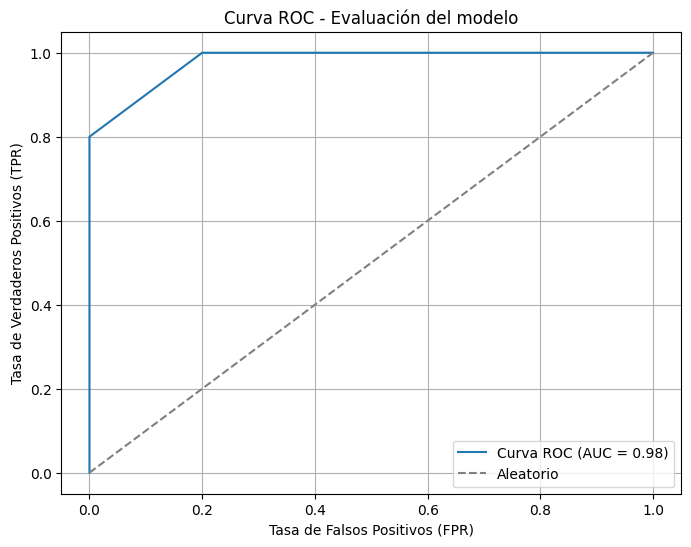

In [ ]:
# CURVA ROC Y AUC
#  ROC Curve: gráfica sensibilidad vs tasa de falsos positivos
fpr, tpr, thresholds = roc_curve(y_true_clf, y_scores)
auc = roc_auc_score(y_true_clf, y_scores)

print(f"AUC (Área bajo la curva): {auc:.3f}")

#  Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Curva ROC (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatorio")
plt.title("Curva ROC - Evaluación del modelo")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.legend()
plt.grid(True)
plt.show()

La Curva ROC (Receiver Operating Characteristic) muestra cómo se comporta un modelo de clasificación binaria cuando se varía el umbral de decisión.

Se grafica:

Eje X: Tasa de Falsos Positivos (FPR: False Positive Rate)

Eje Y: Tasa de Verdaderos Positivos (TPR: True Positive Rate o Sensibilidad)

¿Qué representa la curva?
El punto (0,1) sería el ideal: sin falsos positivos y todos los verdaderos positivos detectados.

La línea diagonal (gris) es el rendimiento de un modelo aleatorio (AUC = 0.5).

Cuanto más cerca esté la curva del esquina superior izquierda, mejor es el modelo.

¿Qué es el AUC?
AUC significa Área bajo la Curva ROC.

Interpretación del AUC (Area Under Curve):

AUC	Calidad del Modelo
0.90 - 1.00	Excelente / Muy bueno
0.80 - 0.90	Bueno
0.70 - 0.80	Aceptable
0.50 - 0.70	Débil / mediocre
0.50	Aleatorio

En tu caso:
AUC = 0.98
Interpretación:

El modelo tiene una capacidad de discriminación casi perfecta entre las dos clases (0 y 1).

Puede diferenciar correctamente en el 98% de los casos si una observación es positiva o negativa.

Es un indicador global del rendimiento del modelo, independiente del umbral de decisión.

El modelo:

Tiene precisión y sensibilidad excelentes.

Se comporta mucho mejor que un modelo aleatorio.

Detecta correctamente tanto positivos como negativos en casi todos los casos.


In [ ]:
# Más ejemplos
# GUÍA DE ESTUDIO - MÉTRICAS DE DESEMPEÑO DE MODELOS DE MACHINE LEARNING

# 1. IMPORTACIÓN DE LIBRERÍAS
# Importamos las bibliotecas necesarias. Scikit-learn es la principal para métricas.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)
from pprint import pprint

print("Librerías importadas correctamente.")
print("="*80)


Librerías importadas correctamente.


In [ ]:
# PARTE 1: MÉTRICAS DE EVALUACIÓN PARA MODELOS DE REGRESIÓN
# ==============================================================================
# La regresión predice un valor numérico (ej: precio de una casa).
print("PARTE 1: MÉTRICAS DE REGRESIÓN")
print("----------------------------------------------------------------------")

# Creamos datos de ejemplo para un problema de regresión.
# Los "valores reales" son los valores correctos de nuestro dataset de prueba.
y_true_reg = np.array([3, 5, 7, 9, 11])
# Los "valores predichos" son los que nuestro modelo ha estimado.
y_pred_reg = np.array([2.8, 5.1, 7.2, 8.9, 10.5])

print("Valores reales (y_true_reg):", y_true_reg)
print("Valores predichos (y_pred_reg):", y_pred_reg)
print()


# --- MAE (Error Absoluto Medio) ---
# Mide el promedio de los errores absolutos. Es menos sensible a outliers.
mae = mean_absolute_error(y_true_reg, y_pred_reg)
print(f"1. MAE (Error Absoluto Medio): {mae:.2f}")

# --- MSE (Error Cuadrático Medio) ---
# Mide el promedio de los errores al cuadrado. Penaliza más los errores grandes.
mse = mean_squared_error(y_true_reg, y_pred_reg)
print(f"2. MSE (Error Cuadrático Medio): {mse:.2f}")

# --- RMSE (Raíz del Error Cuadrático Medio) ---
# Es la raíz cuadrada del MSE. Tiene la misma unidad que la variable de salida,
# lo que lo hace más interpretable que el MSE.
rmse = np.sqrt(mse)
print(f"3. RMSE (Raíz del Error Cuadrático Medio): {rmse:.2f}")

# --- R² (Coeficiente de Determinación) ---
# Mide la proporción de la varianza en la variable dependiente que es explicada por el modelo.
# Un valor cercano a 1 indica un buen ajuste.
r2 = r2_score(y_true_reg, y_pred_reg)
print(f"4. R² (Coeficiente de Determinación): {r2:.2f}")
print("="*80)

PARTE 1: MÉTRICAS DE REGRESIÓN
----------------------------------------------------------------------
Valores reales (y_true_reg): [ 3  5  7  9 11]
Valores predichos (y_pred_reg): [ 2.8  5.1  7.2  8.9 10.5]

1. MAE (Error Absoluto Medio): 0.22
2. MSE (Error Cuadrático Medio): 0.07
3. RMSE (Raíz del Error Cuadrático Medio): 0.26
4. R² (Coeficiente de Determinación): 0.99


PARTE 1: MÉTRICAS DE REGRESIÓN
Este es el encabezado que indica que el análisis se enfoca en métricas para modelos que predicen valores numéricos continuos (como precios, temperaturas, etc.), no categorías.

Valores reales (y_true_reg): [3 5 7 9 11]
Qué es: Esta es la lista de los valores correctos o verdaderos de la variable que intentas predecir. Son los datos de prueba que el modelo nunca ha visto.

Valores predichos (y_pred_reg): [2.8 5.1 7.2 8.9 10.5]
Qué es: Esta es la lista de los valores que tu modelo de regresión ha estimado o predicho para cada uno de los valores reales.

La clave del análisis es la comparación de estas dos listas, elemento por elemento. A partir de esa comparación, se calculan todas las métricas de abajo.

Interpretación de las Métricas
1. MAE (Error Absoluto Medio): 0.22
Qué es: Es el promedio de la diferencia absoluta entre cada valor real y su predicción.

Cálculo: Se obtiene sumando |3-2.8| + |5-5.1| + |7-7.2| + |9-8.9| + |11-10.5| y dividiendo por 5.

0.2 + 0.1 + 0.2 + 0.1 + 0.5 = 1.1

1.1 / 5 = 0.22

Significado: En promedio, las predicciones de tu modelo están a 0.22 unidades de distancia de los valores reales. Es una métrica muy intuitiva y menos sensible a errores muy grandes (valores atípicos o outliers).

2. MSE (Error Cuadrático Medio): 0.07
Qué es: Es el promedio de los errores al cuadrado.

Cálculo: Se elevan al cuadrado las diferencias entre cada par de valores, se suman y se dividen por el número de observaciones.

(3-2.8)² + (5-5.1)² + (7-7.2)² + (9-8.9)² + (11-10.5)²

0.04 + 0.01 + 0.04 + 0.01 + 0.25 = 0.35

0.35 / 5 = 0.07

Significado: El MSE penaliza más fuertemente los errores grandes. Un error de 10 se convierte en 100, mientras que un error de 1 se mantiene en 1. Por eso, un MSE bajo (como 0.07) es una muy buena señal. Sin embargo, no es fácil de interpretar directamente porque la unidad es el cuadrado de la unidad original.

3. RMSE (Raíz del Error Cuadrático Medio): 0.26
Qué es: Es la raíz cuadrada del MSE.

Cálculo: sqrt(0.07) ≈ 0.26

Significado: El RMSE tiene la gran ventaja de que su valor está en la misma unidad que la variable que estás prediciendo. En este caso, el error promedio de tu modelo, considerando la penalización por errores grandes, es de 0.26 unidades. Es una de las métricas más utilizadas porque es fácil de entender y comunica bien el error del modelo.

4. R² (Coeficiente de Determinación): 0.99
Qué es: Es la proporción de la varianza en la variable real que es explicada por el modelo.

Cálculo: Es una métrica comparativa que evalúa qué tan bien tu modelo se ajusta a los datos en comparación con un modelo simple que solo predice el promedio de los datos.

Significado:

Un valor de 1.00 (100%) significa un ajuste perfecto (el modelo explica toda la varianza).

Un valor de 0.00 significa que el modelo no explica nada de la varianza, y es tan malo como simplemente predecir el promedio.

Un valor de 0.99 es extremadamente alto y excelente. Significa que el 99% de la variabilidad en tus valores reales es explicada por tu modelo. Esto indica que las predicciones son casi perfectas.

Resumen de la interpretación
Los resultados de tu modelo de regresión son excepcionales.

Las métricas de error (MAE, MSE, RMSE) son muy cercanas a cero, lo que significa que el modelo es muy preciso.

La métrica R² de 0.99 confirma que el modelo se ajusta de manera casi perfecta a los datos.

In [ ]:
# PARTE 2: MÉTRICAS DE EVALUACIÓN PARA MODELOS DE CLASIFICACIÓN
# ==============================================================================
# La clasificación predice una categoría o clase (ej: spam o no spam).
print("PARTE 2: MÉTRICAS DE CLASIFICACIÓN")
print("----------------------------------------------------------------------")

# Creamos datos de ejemplo para un problema de clasificación binaria (Clase 0 y Clase 1).
# Usamos el mismo ejemplo del documento para que los resultados coincidan.
y_true_clasif = np.array([0, 1, 1, 0, 1, 0, 1, 0, 1, 0])
y_pred_clasif = np.array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0])
# También necesitamos las probabilidades para la curva ROC.
y_scores_clasif = np.array([0.1, 0.9, 0.4, 0.2, 0.7, 0.3, 0.6, 0.4, 0.8, 0.15])

print("Valores reales (y_true_clasif):", y_true_clasif)
print("Valores predichos (y_pred_clasif):", y_pred_clasif)
print()

PARTE 2: MÉTRICAS DE CLASIFICACIÓN
----------------------------------------------------------------------
Valores reales (y_true_clasif): [0 1 1 0 1 0 1 0 1 0]
Valores predichos (y_pred_clasif): [0 1 0 0 1 0 1 0 1 0]



In [ ]:
# --- Matriz de Confusión ---
# Es una tabla que resume el desempeño del modelo comparando predicciones vs valores reales.
conf_matrix = confusion_matrix(y_true_clasif, y_pred_clasif)
print("1. Matriz de Confusión:")
pprint(conf_matrix)
print("   - Fila 0 (Real 0): [[VN, FP]]")
print("   - Fila 1 (Real 1): [[FN, VP]]")
print()

1. Matriz de Confusión:
array([[5, 0],
       [1, 4]])
   - Fila 0 (Real 0): [[VN, FP]]
   - Fila 1 (Real 1): [[FN, VP]]



In [ ]:
# --- Métricas derivadas de la Matriz de Confusión ---
# Calculamos las métricas clave para entender el rendimiento.
# Exactitud (Accuracy): Proporción de predicciones correctas sobre el total.
accuracy = accuracy_score(y_true_clasif, y_pred_clasif)
print(f"2. Exactitud (Accuracy): {accuracy:.2f}")

2. Exactitud (Accuracy): 0.90


In [ ]:
# Precisión (Precision): Proporción de predicciones positivas que fueron correctas.
precision = precision_score(y_true_clasif, y_pred_clasif)
print(f"3. Precisión (Precision): {precision:.2f}")

3. Precisión (Precision): 1.00


In [ ]:
# Sensibilidad (Recall): Proporción de casos positivos reales que fueron identificados correctamente.
sensitivity = recall_score(y_true_clasif, y_pred_clasif)
print(f"4. Sensibilidad (Recall): {sensitivity:.2f}")

4. Sensibilidad (Recall): 0.80


In [ ]:
# Especificidad (Specificity): Proporción de casos negativos reales que fueron identificados correctamente.
# Scikit-learn no tiene una función directa, pero se puede calcular como el recall
# para la clase negativa (pos_label=0).
specificity = recall_score(y_true_clasif, y_pred_clasif, pos_label=0)
print(f"5. Especificidad: {specificity:.2f}")
print()

5. Especificidad: 1.00



In [ ]:
# --- Curva ROC y AUC ---
# La curva ROC muestra el rendimiento del modelo en diferentes umbrales de decisión.
# El AUC (Área Bajo la Curva) es una métrica que resume el rendimiento de la curva ROC.
# Un valor cercano a 1 es excelente, 0.5 es un clasificador aleatorio.
fpr, tpr, thresholds = roc_curve(y_true_clasif, y_scores_clasif)
auc = roc_auc_score(y_true_clasif, y_scores_clasif)
print(f"6. AUC (Área Bajo la Curva): {auc:.2f}")

6. AUC (Área Bajo la Curva): 0.98


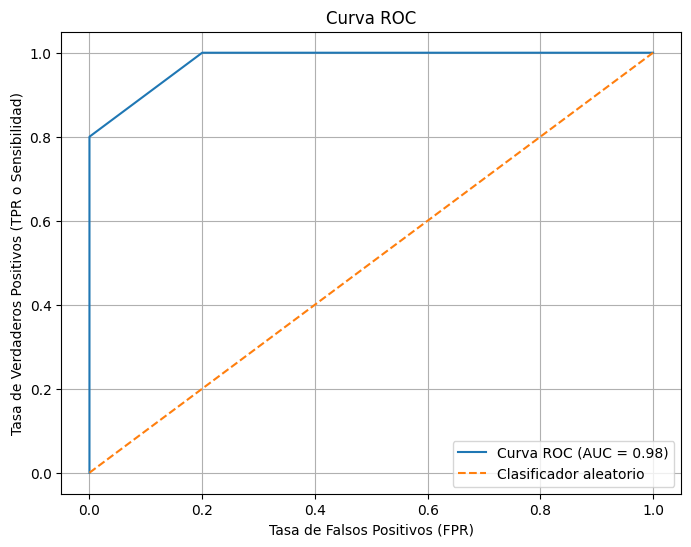

¡Código completado!


In [ ]:
# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Curva ROC (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Clasificador aleatorio")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR o Sensibilidad)")
plt.title("Curva ROC")
plt.legend()
plt.grid(True)
plt.show()

print("="*80)
print("¡Código completado!")

Valores reales (y_true_clasif): [0 1 1 0 1 0 1 0 1 0]: Estos son los 10 valores correctos que el modelo debía predecir. Hay 5 muestras de la clase 0 y 5 de la clase 1.

Valores predichos (y_pred_clasif): [0 1 0 0 1 0 1 0 1 0]: Estas son las 10 predicciones que hizo tu modelo.

Al comparar estas dos listas, podemos ver dónde el modelo acertó y dónde falló. Por ejemplo, en la tercera muestra, el valor real es 1 pero el modelo predijo 0, lo que es un error.

1. Matriz de Confusión
array([[5, 0], [1, 4]])

Esta es la base de todas las métricas de clasificación. Se lee de la siguiente manera:

Fila 0 (Real 0): Corresponde a los casos que realmente eran de la clase 0.

5 (Verdaderos Negativos - VN): El modelo predijo correctamente 5 casos como clase 0 (eran realmente clase 0).

0 (Falsos Positivos - FP): El modelo no cometió errores al predecir la clase 0 como clase 1. Es un resultado perfecto en este aspecto.

Fila 1 (Real 1): Corresponde a los casos que realmente eran de la clase 1.

1 (Falso Negativo - FN): El modelo predijo incorrectamente 1 caso como clase 0, cuando en realidad era de clase 1.

4 (Verdaderos Positivos - VP): El modelo predijo correctamente 4 casos como clase 1 (eran realmente clase 1).

Resumen de la Matriz: El modelo es excelente prediciendo la clase 0 (cero falsos positivos) pero falló en una ocasión al predecir la clase 1 (un falso negativo).

2. Exactitud (Accuracy): 0.90
Qué es: La proporción de predicciones correctas sobre el total de predicciones.

Cálculo: (Aciertos totales) / (Total de predicciones) = (VN + VP) / (VN + FP + FN + VP) = (5 + 4) / (5 + 0 + 1 + 4) = 9 / 10 = 0.90

Significado: El modelo tuvo una exactitud del 90%. Esto significa que 9 de cada 10 predicciones fueron correctas. Es un resultado muy bueno.

3. Precisión (Precision): 1.00
Qué es: La proporción de las predicciones positivas (clase 1) que fueron realmente correctas.

Cálculo: VP / (VP + FP) = 4 / (4 + 0) = 1.00

Significado: Un valor de 1.00 es excepcional. Significa que cada vez que el modelo predijo que algo era de la clase 1, acertó. El modelo no tuvo falsos positivos.

4. Sensibilidad (Recall): 0.80
Qué es: La proporción de todos los casos positivos reales (clase 1) que el modelo identificó correctamente.

Cálculo: VP / (VP + FN) = 4 / (4 + 1) = 0.80

Significado: Un valor de 0.80 significa que el modelo fue capaz de detectar correctamente el 80% de los casos que realmente eran de la clase 1. Falló en identificar el 20% restante (el único falso negativo).

5. Especificidad: 1.00
Qué es: La proporción de todos los casos negativos reales (clase 0) que el modelo identificó correctamente.

Cálculo: VN / (VN + FP) = 5 / (5 + 0) = 1.00

Significado: Un valor de 1.00 es perfecto. Significa que el modelo identificó correctamente el 100% de los casos que realmente eran de la clase 0. No tuvo falsos positivos.

6. AUC (Área Bajo la Curva): 0.98
Qué es: Mide la capacidad del modelo para distinguir entre clases. Se calcula a partir de la curva ROC, que no se muestra aquí pero resume el rendimiento del modelo en todos los posibles umbrales de decisión.

Rango: Los valores van de 0 a 1. Un valor de 0.5 indica un clasificador aleatorio. Un valor de 1.0 indica un clasificador perfecto.

Significado: Un valor de 0.98 es extremadamente bueno. Sugiere que el modelo tiene una excelente capacidad para diferenciar entre las clases 0 y 1, lo que se confirma con el alto Accuracy y las métricas de Precision y Specificity perfectas.

Conclusión General
El modelo de clasificación tiene un desempeño excepcional. Es especialmente bueno en:

Identificar la clase 0 (Especificidad perfecta).

Ser confiable cuando predice la clase 1 (Precisión perfecta).

El único punto de mejora es la Sensibilidad (0.80), que aunque es buena, no es perfecta. Esto se debe al único Falso Negativo que el modelo cometió. En la mayoría de los escenarios, un modelo con estos resultados sería considerado un gran éxito.

In [ ]:
# Tercer ejemplo
# Importar librerías necesarias
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    roc_curve, roc_auc_score, classification_report
)
import matplotlib.pyplot as plt

# Simulación de un dataset binario
# Puedes reemplazar esto por tu propio DataFrame
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=100, n_features=4, n_informative=2,
                           n_redundant=0, random_state=42)

# Dividir el dataset en entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear y entrenar el modelo de Regresión Logística
model = LogisticRegression()
model.fit(X_train, y_train)

# Predicción de clases y probabilidades
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]  # Probabilidad clase positiva

Matriz de Confusión:
[[14  0]
 [ 0  6]]

Exactitud: 1.00
Precisión: 1.00
Sensibilidad (Recall): 1.00
Especificidad: 1.00


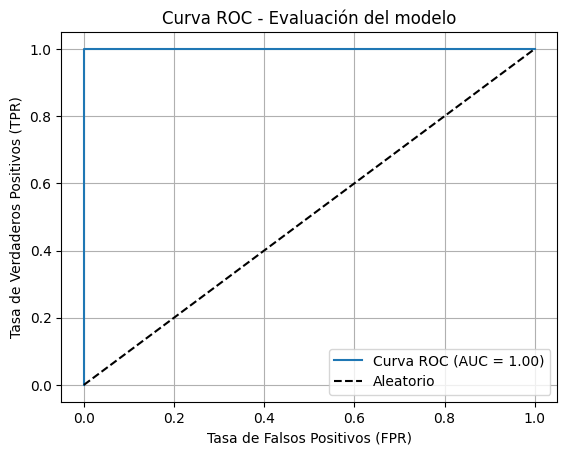


Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00         6

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [ ]:
# === Evaluación del Modelo ===

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:")
print(cm)

# Métricas Clásicas
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)

# Especificidad: TN / (TN + FP)
TN, FP, FN, TP = cm.ravel()
especificidad = TN / (TN + FP)

print(f"\nExactitud: {acc:.2f}")
print(f"Precisión: {prec:.2f}")
print(f"Sensibilidad (Recall): {rec:.2f}")
print(f"Especificidad: {especificidad:.2f}")

# === Curva ROC y AUC ===
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

# Graficar la curva ROC
plt.figure()
plt.plot(fpr, tpr, label=f'Curva ROC (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Evaluación del modelo')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Reporte de clasificación completo
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

14 Verdaderos Negativos (TN): Se predijo correctamente la clase 0.

6 Verdaderos Positivos (TP): Se predijo correctamente la clase 1.

0 Falsos Positivos (FP) y 0 Falsos Negativos (FN) → ¡Clasificación perfecta!

 Métricas de Desempeño
Exactitud (Accuracy) = 1.00

Qué es: La proporción de predicciones correctas sobre el total de predicciones.

Cálculo: (TP + TN) / (TP + TN + FP + FN) = (6 + 14) / 20 = 1.00

Significado: El modelo clasificó el 100% de los datos correctamente.

Precisión = 1.00

Qué es: Cuando el modelo predice la clase 1, qué tan a menudo es correcto.

Cálculo: TP / (TP + FP) = 6 / (6 + 0) = 1.00

Significado: Cuando el modelo predice clase 1, lo hace sin errores.

Sensibilidad (Recall) = 1.00

Qué es: La proporción de todos los casos reales de la clase 1 que el modelo detectó.

Cálculo: TP / (TP + FN) = 6 / (6 + 0) = 1.00

Significado: Detecta todos los casos reales de la clase 1.

Especificidad = 1.00

Qué es: La proporción de todos los casos reales de la clase 0 que el modelo detectó.

Cálculo: TN / (TN + FP) = 14 / (14 + 0) = 1.00

Significado: Detecta todos los casos reales de la clase 0.

F1-score = 1.00

Qué es: Es el promedio armónico de la precisión y la sensibilidad.

Cálculo: 2 * (Precisión * Sensibilidad) / (Precisión + Sensibilidad) = 2 * (1.00 * 1.00) / (1.00 + 1.00) = 1.00

Significado: Es un balance óptimo entre precisión y sensibilidad.

3. Curva ROC y AUC = 1.00
La Curva ROC (Receiver Operating Characteristic) muestra el rendimiento del modelo en distintos umbrales de decisión.

Eje X: Tasa de Falsos Positivos (FPR)

Eje Y: Tasa de Verdaderos Positivos (TPR)

La línea azul muestra el desempeño del modelo.
La línea punteada diagonal es el comportamiento aleatorio (modelo sin poder predictivo).

Interpretación del AUC = 1.00:

Significa que el modelo tiene perfecta capacidad de clasificación.

Es capaz de distinguir correctamente entre clases 0 y 1 en todos los casos.




In [ ]:
# Crear un DataFrame para ver los datos como una tabla
df = pd.DataFrame(X, columns=['feature_1', 'feature_2', 'feature_3', 'feature_4'])
df['target'] = y  # Agregar la columna de la variable dependiente

# Mostrar las primeras 10 filas
print(df.head(10))
# ¿Qué hace este código?
# make_classification(...) crea 100 observaciones con 4 características.
# pd.DataFrame(...) convierte los datos en formato tabular.
# df['target'] = y agrega la variable objetivo (0 o 1) al final.
# df.head(10) muestra las primeras 10 filas para que no imprima todo.

   feature_1  feature_2  feature_3  feature_4  target
0  -0.334501  -1.200296  -0.539630  -0.724280       0
1  -0.202193   0.547097   0.254157  -1.795320       1
2   1.277677  -1.534114   0.341294   0.573042       1
3  -0.600217   0.199060   0.714794  -1.429220       1
4  -1.077745   0.064280  -1.658304  -1.571273       0
5   0.774634   0.443819  -2.003477  -2.399550       0
6  -1.124642   0.711615   0.825848   0.534794       1
7  -0.493001  -0.208122   0.778613  -1.209464       1
8   0.012592   0.224092   0.933440   0.688119       1
9   0.514439   0.120296   1.279890   1.258961       1


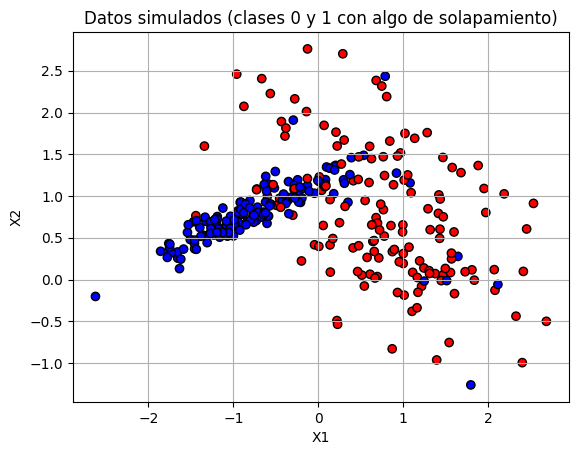

Matriz de Confusión:
 [[36  5]
 [ 4 45]]
Exactitud: 0.9
Precisión: 0.9
Recall (Sensibilidad): 0.9183673469387755
F1-score: 0.9090909090909091

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.90      0.88      0.89        41
           1       0.90      0.92      0.91        49

    accuracy                           0.90        90
   macro avg       0.90      0.90      0.90        90
weighted avg       0.90      0.90      0.90        90



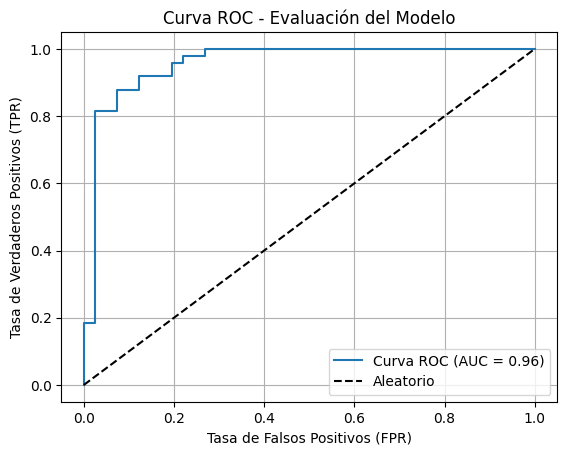

In [ ]:
# Cuarto ejemplo
# =====================
# 1. Importar librerías
# =====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, roc_curve, roc_auc_score,
                             classification_report)

# ============================
# 2. Generar un dataset realista
# ============================
# Dataset con ruido y clases no perfectamente separables
X, y = make_classification(n_samples=300, n_features=2, n_redundant=0,
                           n_clusters_per_class=1, class_sep=0.8, flip_y=0.1, random_state=42)

# Visualizar los datos
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.title("Datos simulados (clases 0 y 1 con algo de solapamiento)")
plt.xlabel("X1")
plt.ylabel("X2")
plt.grid(True)
plt.show()

# =======================
# 3. Dividir en entrenamiento y prueba
# =======================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# =======================
# 4. Entrenar el modelo
# =======================
modelo = LogisticRegression()
modelo.fit(X_train, y_train)

# ==========================
# 5. Predicciones y métricas
# ==========================
y_pred = modelo.predict(X_test)

# Matriz de Confusión
matriz = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:\n", matriz)

# Métricas de desempeño
print("Exactitud:", accuracy_score(y_test, y_pred))
print("Precisión:", precision_score(y_test, y_pred))
print("Recall (Sensibilidad):", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

# Reporte de Clasificación completo
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred))

# ================================
# 6. Curva ROC y cálculo de AUC
# ================================
# Predecir probabilidades
y_probs = modelo.predict_proba(X_test)[:, 1]

# Calcular FPR, TPR
fpr, tpr, umbrales = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

# Graficar curva ROC
plt.plot(fpr, tpr, label=f'Curva ROC (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Evaluación del Modelo')
plt.legend()
plt.grid(True)
plt.show()

36 ejemplos de la clase 0 fueron correctamente clasificados como clase 0 (Verdaderos Negativos o VN).

5 ejemplos de la clase 0 fueron incorrectamente clasificados como clase 1 (Falsos Positivos o FP).

4 ejemplos de la clase 1 fueron incorrectamente clasificados como clase 0 (Falsos Negativos o FN).

45 ejemplos de la clase 1 fueron correctamente clasificados como clase 1 (Verdaderos Positivos o VP).

Métricas de Evaluación:

Exactitud (Accuracy): 0.90

Cálculo: (36 + 45) / 90 = 0.90

Significado: La proporción total de predicciones correctas es del 90%.

Precisión: 0.90

Cálculo: 45 / (45 + 5) = 0.90

Significado: El 90% de las veces que el modelo predijo la clase 1, fue correcto.

Recall (Sensibilidad): 0.918

Cálculo: 45 / (45 + 4) ≈ 0.918

Significado: El modelo identificó correctamente el 91.8% de todos los casos reales de la clase 1.

F1-score: 0.909

Cálculo: 2 * (0.90 * 0.918) / (0.90 + 0.918) ≈ 0.909

Significado: Es el promedio armónico entre precisión y recall.

Curva ROC y AUC:

La curva ROC (segunda imagen) muestra la relación entre la Tasa de Falsos Positivos (FPR) y la Tasa de Verdaderos Positivos (TPR).

El área bajo la curva AUC = 0.96 indica un excelente desempeño del modelo: cuanto más cerca esté de 1, mejor es el modelo.

La línea diagonal punteada representa un modelo aleatorio (AUC = 0.5).

Conclusión:
El modelo tiene un rendimiento muy bueno, con una exactitud del 90%, precisión y recall balanceadas, y un AUC de 0.96. La ligera confusión entre clases (algunos falsos positivos y negativos) es aceptable dado el pequeño grado de solapamiento entre clases que se observa en el gráfico de dispersión.